Running Final Corrected Diffusion on cuda...
Loading CLIP (Visual Only)...
Starting Diffusion Training on 5000 images...


/tmp/ipykernel_703089/3471092567.py:247: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if CONFIG['device'] == 'cuda' else None
/tmp/ipykernel_703089/3471092567.py:264: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Batch 0 | Loss: 1.3517
Epoch 1 | Batch 50 | Loss: 0.2204
Epoch 1 | Batch 100 | Loss: 0.1469
Epoch 1 | Batch 150 | Loss: 0.1299
Epoch 1 | Batch 200 | Loss: 0.1164
Epoch 1 | Batch 250 | Loss: 0.0610
Epoch 1 | Batch 300 | Loss: 0.1241
Epoch 1 Avg Loss: 0.1652
Epoch 2 | Batch 0 | Loss: 0.1596
Epoch 2 | Batch 50 | Loss: 0.0640
Epoch 2 | Batch 100 | Loss: 0.0763
Epoch 2 | Batch 150 | Loss: 0.0438
Epoch 2 | Batch 200 | Loss: 0.0664
Epoch 2 | Batch 250 | Loss: 0.0968
Epoch 2 | Batch 300 | Loss: 0.0803
Epoch 2 Avg Loss: 0.0812
Epoch 3 | Batch 0 | Loss: 0.0676
Epoch 3 | Batch 50 | Loss: 0.0686
Epoch 3 | Batch 100 | Loss: 0.0916
Epoch 3 | Batch 150 | Loss: 0.0428
Epoch 3 | Batch 200 | Loss: 0.1032
Epoch 3 | Batch 250 | Loss: 0.0536
Epoch 3 | Batch 300 | Loss: 0.0413
Epoch 3 Avg Loss: 0.0704
Epoch 4 | Batch 0 | Loss: 0.0335
Epoch 4 | Batch 50 | Loss: 0.0698
Epoch 4 | Batch 100 | Loss: 0.0863
Epoch 4 | Batch 150 | Loss: 0.0817
Epoch 4 | Batch 200 | Loss: 0.1175
Epoch 4 | Batch 250 | Loss:

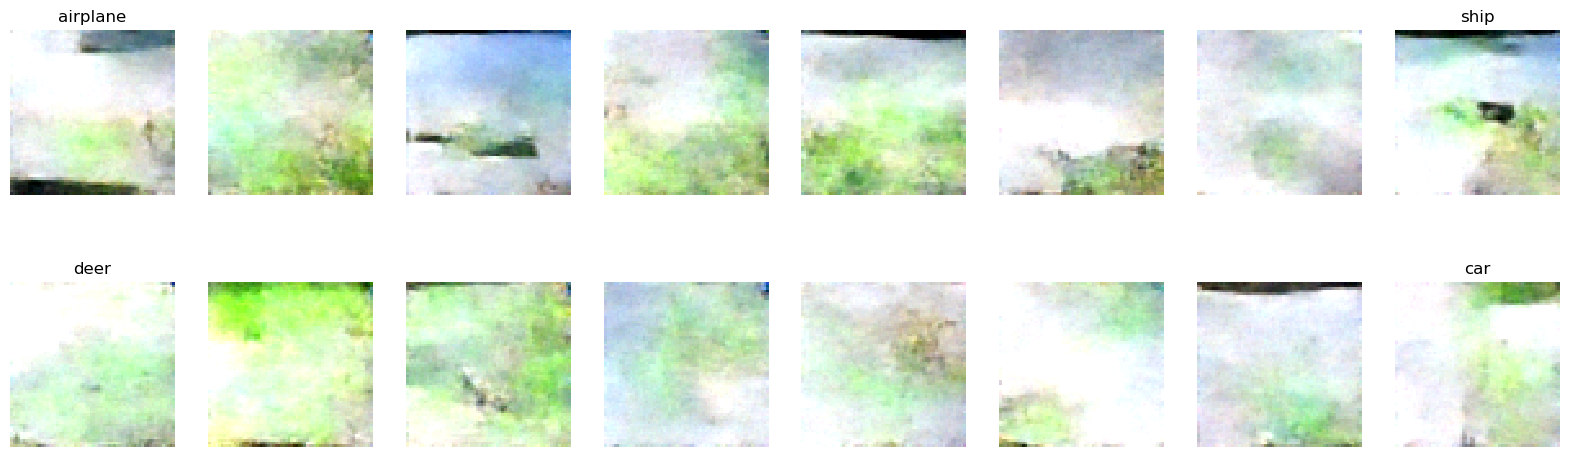

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import gc

# -----------------------------------------------------------------------------
# 0. CONFIGURATION & MEMORY CLEANUP
# -----------------------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")
    exit()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 16,     
    "lr": 2e-4,
    "epochs": 15,
    "img_size": 64,
    "timesteps": 500,
    "embed_dim": 512,
    "output_dir": "stl10_diffusion_outputs"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Running Final Corrected Diffusion on {CONFIG['device']}...")

# -----------------------------------------------------------------------------
# 1. DATASET
# -----------------------------------------------------------------------------
def get_stl10_loader():
    transform = T.Compose([
        T.Resize(CONFIG['img_size']),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    download = not os.path.exists('./data/stl10_binary')
    dataset = datasets.STL10(root='./data', split='train', download=download, transform=transform)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    return loader, dataset

# -----------------------------------------------------------------------------
# 2. DIFFUSION SCHEDULER
# -----------------------------------------------------------------------------
class DiffusionScheduler:
    def __init__(self, timesteps=500, start=0.0001, end=0.02, device="cpu"):
        self.timesteps = timesteps
        self.device = device
        self.betas = torch.linspace(start, end, timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1.0 - self.alpha_hat)

    def noise_images(self, x, t):
        sqrt_alpha_hat = self.sqrt_alpha_hat[t][:, None, None, None]
        sqrt_one_minus_alpha_hat = self.sqrt_one_minus_alpha_hat[t][:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise, noise

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.timesteps, size=(n,)).to(self.device)

# -----------------------------------------------------------------------------
# 3. MODELS: CORRECTED ARCHITECTURE
# -----------------------------------------------------------------------------
class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        print("Loading CLIP (Visual Only)...")
        # Load full model to CPU first
        full_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device='cpu')
        
        # Extract visual encoder
        self.visual = full_model.visual
        self.visual.eval()
        
        # Cleanup
        del full_model
        gc.collect()
        torch.cuda.empty_cache()
        
        self.register_buffer("mean", torch.tensor([0.481, 0.457, 0.408]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.268, 0.261, 0.275]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images):
        x = (images + 1) * 0.5
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = (x - self.mean) / self.std
        features = self.visual(x)
        return features.float() / features.norm(dim=-1, keepdim=True)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """
    Standard ResNet-ish block. Maintains resolution (No up/down sampling inside).
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bn1(self.relu(self.conv1(x)))
        # Add Time Embedding
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bn2(self.relu(self.conv2(h)))
        return h

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        # Architecture: 64 -> 128 -> 256 -> Bottleneck -> 256 -> 128 -> 64
        down_channels = (64, 128, 256) 
        up_channels = (256, 128, 64)
        time_emb_dim = 128
        clip_emb_dim = 512

        # 1. Conditioning Projection
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # 2. Initial Conv (No downsample yet)
        self.inc = Block(image_channels, 64, time_emb_dim)

        # 3. Downsampling Path
        self.down1 = Block(64, 128, time_emb_dim)
        self.down2 = Block(128, 256, time_emb_dim)
        
        self.pool = nn.MaxPool2d(2)

        # 4. Bottleneck
        self.bot1 = Block(256, 256, time_emb_dim)
        self.bot2 = Block(256, 256, time_emb_dim)

        # 5. Upsampling Path
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.up_block1 = Block(128 + 256, 128, time_emb_dim) # 128 from up + 256 from skip

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.up_block2 = Block(64 + 128, 64, time_emb_dim)   # 64 from up + 128 from skip
        
        self.up3 = nn.ConvTranspose2d(64, 64, 2, 2) 
        self.up_block3 = Block(64 + 64, 64, time_emb_dim)    # 64 from up + 64 from initial

        # 6. Output
        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x, timestep, clip_emb):
        t = self.time_mlp(timestep)
        c = self.clip_proj(clip_emb)
        t = t + c # Inject Context

        # --- Encoder ---
        x1 = self.inc(x, t)        # 64x64, 64ch
        
        x2 = self.pool(x1)         # 32x32
        x2 = self.down1(x2, t)     # 32x32, 128ch
        
        x3 = self.pool(x2)         # 16x16
        x3 = self.down2(x3, t)     # 16x16, 256ch
        
        x4 = self.pool(x3)         # 8x8
        
        # --- Bottleneck ---
        x4 = self.bot1(x4, t)
        x4 = self.bot2(x4, t)      # 8x8, 256ch

        # --- Decoder ---
        
        # Up 1 (8 -> 16)
        x = self.up1(x4)           # 16x16, 128ch
        # Skip connection from x3 (16x16, 256ch)
        x = torch.cat([x, x3], dim=1) 
        x = self.up_block1(x, t)   # 16x16, 128ch

        # Up 2 (16 -> 32)
        x = self.up2(x)            # 32x32, 64ch
        # Skip connection from x2 (32x32, 128ch)
        x = torch.cat([x, x2], dim=1)
        x = self.up_block2(x, t)   # 32x32, 64ch

        # Up 3 (32 -> 64)
        x = self.up3(x)            # 64x64, 64ch
        # Skip connection from x1 (64x64, 64ch)
        x = torch.cat([x, x1], dim=1)
        x = self.up_block3(x, t)   # 64x64, 64ch

        return self.outc(x)

# -----------------------------------------------------------------------------
# 4. TRAINING
# -----------------------------------------------------------------------------
def train_diffusion():
    loader, dataset = get_stl10_loader()
    
    encoder = CLIPEncoder().to(CONFIG['device'])
    model = SimpleUNet().to(CONFIG['device'])
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'])
    mse = nn.MSELoss()
    diffusion = DiffusionScheduler(timesteps=CONFIG['timesteps'], device=CONFIG['device'])
    
    print(f"Starting Diffusion Training on {len(dataset)} images...")
    
    scaler = torch.cuda.amp.GradScaler() if CONFIG['device'] == 'cuda' else None
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        total_loss = 0
        
        for i, (images, _) in enumerate(loader):
            images = images.to(CONFIG['device'])
            t = diffusion.sample_timesteps(images.shape[0])
            x_t, noise = diffusion.noise_images(images, t)
            
            with torch.no_grad():
                clip_emb = encoder(images)
            
            optimizer.zero_grad()
            
            if CONFIG['device'] == 'cuda':
                with torch.cuda.amp.autocast():
                    predicted_noise = model(x_t, t, clip_emb)
                    loss = mse(noise, predicted_noise)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                predicted_noise = model(x_t, t, clip_emb)
                loss = mse(noise, predicted_noise)
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            
            if i % 50 == 0:
                print(f"Epoch {epoch+1} | Batch {i} | Loss: {loss.item():.4f}")
                
        print(f"Epoch {epoch+1} Avg Loss: {total_loss/len(loader):.4f}")
        
    return encoder, model, diffusion, dataset

# -----------------------------------------------------------------------------
# 5. VIZ
# -----------------------------------------------------------------------------
def sample(model, diffusion, clip_emb):
    model.eval()
    n = clip_emb.shape[0]
    x = torch.randn((n, 3, CONFIG['img_size'], CONFIG['img_size'])).to(CONFIG['device'])
    
    with torch.no_grad():
        for i in reversed(range(1, diffusion.timesteps)):
            t = (torch.ones(n) * i).long().to(CONFIG['device'])
            predicted_noise = model(x, t, clip_emb)
            
            alpha = diffusion.alphas[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.betas[t][:, None, None, None]
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu().permute(0, 2, 3, 1).numpy()

def visualize_diffusion_blends(encoder, model, diffusion, dataset):
    print("Generating Diffusion Blends...")
    class_map = {0: 'airplane', 8: 'ship', 4: 'deer', 2: 'car'}
    examples = {}
    indices = np.random.permutation(len(dataset))
    for idx in indices:
        img, label = dataset[idx]
        if label not in examples: examples[label] = img
        if len(examples) == 10: break

    pairs = [(0, 8), (4, 2)]
    steps = 8
    
    fig, axes = plt.subplots(len(pairs), steps, figsize=(20, 3 * len(pairs)))
    
    with torch.no_grad():
        for row, (c1, c2) in enumerate(pairs):
            img1 = examples[c1].unsqueeze(0).to(CONFIG['device'])
            img2 = examples[c2].unsqueeze(0).to(CONFIG['device'])
            
            emb1 = encoder(img1)
            emb2 = encoder(img2)
            
            alphas = np.linspace(0, 1, steps)
            
            for col, alpha in enumerate(alphas):
                # Interpolation
                theta = torch.acos(torch.sum(emb1 * emb2))
                sin_theta = torch.sin(theta)
                if sin_theta < 1e-6:
                     mixed_emb = (1-alpha)*emb1 + alpha*emb2
                else:
                    w1 = torch.sin((1-alpha)*theta)/sin_theta
                    w2 = torch.sin(alpha*theta)/sin_theta
                    mixed_emb = w1*emb1 + w2*emb2
                
                generated_img = sample(model, diffusion, mixed_emb)
                
                ax = axes[row, col]
                ax.imshow(generated_img[0])
                ax.axis('off')
                
                if col == 0: ax.set_title(class_map.get(c1, ''))
                if col == steps - 1: ax.set_title(class_map.get(c2, ''))

    save_path = f"{CONFIG['output_dir']}/diffusion_blends.png"
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Saved to {save_path}")

if __name__ == "__main__":
    enc, model, diff, ds = train_diffusion()
    visualize_diffusion_blends(enc, model, diff, ds)

 Model saved to stl10_diffusion_v2.pth
Visualizing emergence (Timeline of creation)...


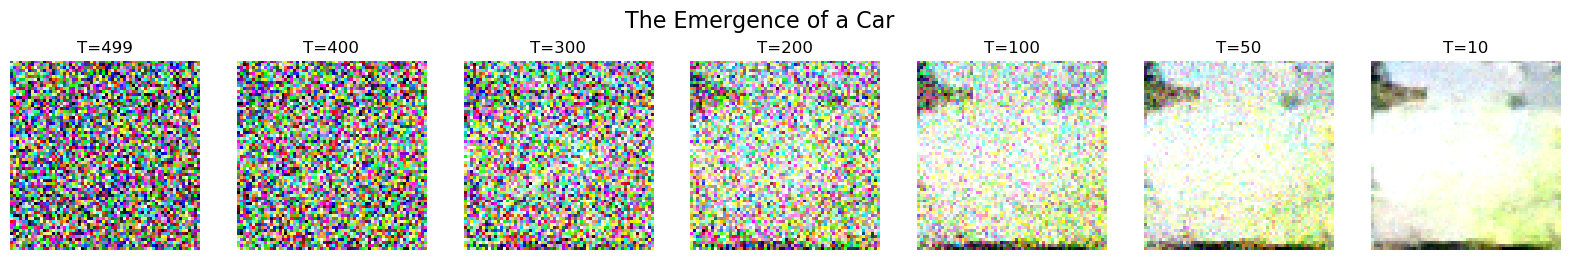

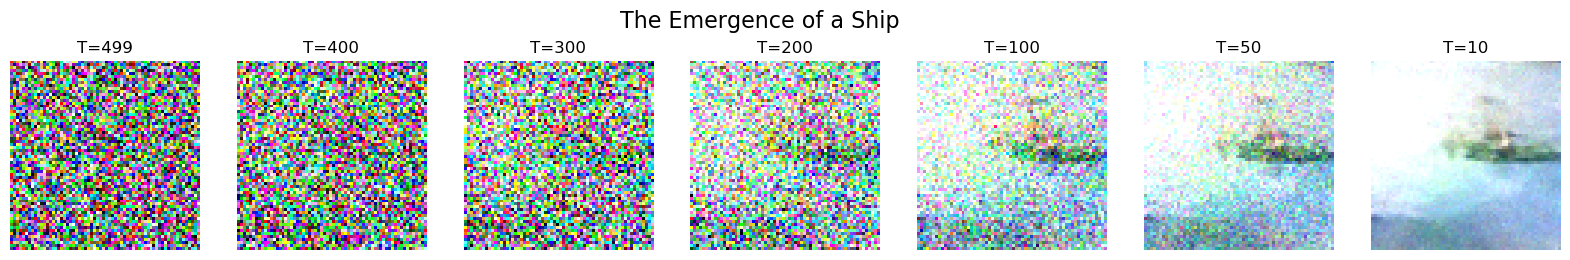

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SAVE YOUR MODEL (Critical!)
# ==========================================
if 'model' in globals():
    torch.save(model.state_dict(), "stl10_diffusion_v2.pth")
    print(" Model saved to stl10_diffusion_v2.pth")
else:
    print(" Model not found in memory. Did you restart the kernel?")

# ==========================================
# 2. WATCH THE "DENOISING" PROCESS
# ==========================================
def sample_history(model, diffusion, clip_emb):
    """
    Runs diffusion but captures snapshots at specific timesteps.
    """
    model.eval()
    n = clip_emb.shape[0]
    x = torch.randn((n, 3, 64, 64)).to(CONFIG['device'])
    
    # We want to see: Pure Noise -> Rough Shape -> Details -> Final
    # Timesteps run from 499 down to 0
    capture_steps = [499, 400, 300, 200, 100, 50, 10, 0]
    history = []
    
    with torch.no_grad():
        for i in reversed(range(1, diffusion.timesteps)):
            t = (torch.ones(n) * i).long().to(CONFIG['device'])
            predicted_noise = model(x, t, clip_emb)
            
            alpha = diffusion.alphas[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.betas[t][:, None, None, None]
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            
            if i in capture_steps:
                img = (x.clamp(-1, 1) + 1) / 2
                img = img.cpu().permute(0, 2, 3, 1).numpy()[0]
                history.append((i, img))
                
    return history

def visualize_emergence(encoder, model, diffusion, dataset):
    print("Visualizing emergence (Timeline of creation)...")
    
    # Let's find a Car (Class 2) and a Ship (Class 8)
    targets = {2: 'Car', 8: 'Ship'}
    
    for cls_idx, name in targets.items():
        # Find image
        target_img = None
        for img, label in dataset:
            if label == cls_idx:
                target_img = img.unsqueeze(0).to(CONFIG['device'])
                break
        
        # Get Concept Vector
        with torch.no_grad():
            emb = encoder(target_img)
            
        # Run process
        steps = sample_history(model, diffusion, emb)
        
        # Plot
        fig, axes = plt.subplots(1, len(steps), figsize=(20, 3))
        fig.suptitle(f"The Emergence of a {name}", fontsize=16)
        
        for idx, (t, img) in enumerate(steps):
            axes[idx].imshow(img)
            axes[idx].set_title(f"T={t}")
            axes[idx].axis('off')
            
        plt.show()

if 'model' in globals():
    visualize_emergence(enc, model, diff, ds)

/home/gedo/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files already downloaded and verified


/tmp/ipykernel_705805/771307372.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting Training...


/tmp/ipykernel_705805/771307372.py:212: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Ep 1 Batch 0 Loss: 1.3514
Ep 1 Batch 50 Loss: 0.1871
Ep 1 Batch 100 Loss: 0.1412
Ep 1 Batch 150 Loss: 0.1573
Ep 1 Batch 200 Loss: 0.1215
Ep 1 Batch 250 Loss: 0.0799
Ep 1 Batch 300 Loss: 0.0883
Ep 2 Batch 0 Loss: 0.1168
Ep 2 Batch 50 Loss: 0.0382
Ep 2 Batch 100 Loss: 0.0645
Ep 2 Batch 150 Loss: 0.0744
Ep 2 Batch 200 Loss: 0.0684
Ep 2 Batch 250 Loss: 0.0859
Ep 2 Batch 300 Loss: 0.0504
Ep 3 Batch 0 Loss: 0.0612
Ep 3 Batch 50 Loss: 0.0496
Ep 3 Batch 100 Loss: 0.0698
Ep 3 Batch 150 Loss: 0.0703
Ep 3 Batch 200 Loss: 0.0927
Ep 3 Batch 250 Loss: 0.0923
Ep 3 Batch 300 Loss: 0.0538
Ep 4 Batch 0 Loss: 0.0556
Ep 4 Batch 50 Loss: 0.0801
Ep 4 Batch 100 Loss: 0.0554
Ep 4 Batch 150 Loss: 0.0863
Ep 4 Batch 200 Loss: 0.0440
Ep 4 Batch 250 Loss: 0.0682
Ep 4 Batch 300 Loss: 0.0483
Ep 5 Batch 0 Loss: 0.1618
Ep 5 Batch 50 Loss: 0.0343
Ep 5 Batch 100 Loss: 0.0902
Ep 5 Batch 150 Loss: 0.0266
Ep 5 Batch 200 Loss: 0.0584
Ep 5 Batch 250 Loss: 0.0895
Ep 5 Batch 300 Loss: 0.1194
Ep 6 Batch 0 Loss: 0.0495
Ep 6 Batc

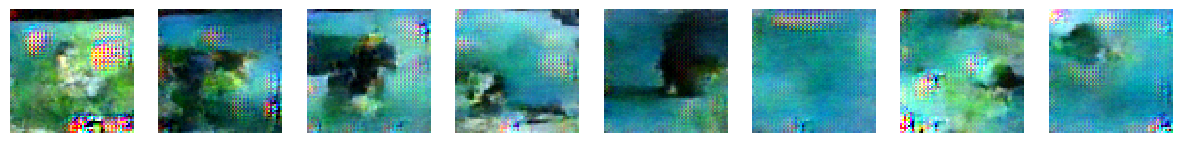

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import gc

# -----------------------------------------------------------------------------
# 0. MEMORY NUKE
# -----------------------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 16,     
    "lr": 2e-4,
    "epochs": 15,
    "img_size": 64,
    "timesteps": 500,
    "embed_dim": 512,
    "output_dir": "stl10_diffusion_outputs"
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# -----------------------------------------------------------------------------
# 1. MODELS (Explicit Shapes)
# -----------------------------------------------------------------------------
try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")

class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Load to CPU to save VRAM
        full_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device='cpu')
        self.visual = full_model.visual
        self.visual.eval()
        del full_model
        gc.collect()
        
        self.register_buffer("mean", torch.tensor([0.481, 0.457, 0.408]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.268, 0.261, 0.275]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images):
        x = (images + 1) * 0.5
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = (x - self.mean) / self.std
        features = self.visual(x)
        return features.float() / features.norm(dim=-1, keepdim=True)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    # Standard ResNet block - NO resizing inside
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bn1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bn2(self.relu(self.conv2(h)))
        return h

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Layers
        time_emb_dim = 128
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.clip_proj = nn.Sequential(
            nn.Linear(512, time_emb_dim),
            nn.ReLU()
        )
        
        # DOWN
        self.inc = Block(3, 64, time_emb_dim)       # 64
        self.down1 = Block(64, 128, time_emb_dim)   # 32
        self.down2 = Block(128, 256, time_emb_dim)  # 16
        
        self.pool = nn.MaxPool2d(2)
        
        # BOTTLENECK
        self.bot1 = Block(256, 256, time_emb_dim)
        self.bot2 = Block(256, 256, time_emb_dim)
        
        # UP (Explicitly defined to prevent loop errors)
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.up_block1 = Block(128 + 256, 128, time_emb_dim)
        
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.up_block2 = Block(64 + 128, 64, time_emb_dim)
        
        self.up3 = nn.ConvTranspose2d(64, 64, 2, 2)
        self.up_block3 = Block(64 + 64, 64, time_emb_dim)
        
        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x, timestep, clip_emb):
        t = self.time_mlp(timestep) + self.clip_proj(clip_emb)

        # DOWN
        x1 = self.inc(x, t)        # 64x64
        x2 = self.down1(self.pool(x1), t) # 32x32
        x3 = self.down2(self.pool(x2), t) # 16x16
        x4 = self.pool(x3)         # 8x8
        
        # BOTTLENECK
        x4 = self.bot1(x4, t)
        x4 = self.bot2(x4, t)      # 8x8

        # UP
        # 1. 8 -> 16. Concat with x3 (16)
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.up_block1(x, t)
        
        # 2. 16 -> 32. Concat with x2 (32)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_block2(x, t)
        
        # 3. 32 -> 64. Concat with x1 (64)
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_block3(x, t)
        
        return self.outc(x)

# -----------------------------------------------------------------------------
# 2. TRAINING
# -----------------------------------------------------------------------------
class DiffusionScheduler:
    def __init__(self, timesteps=500, device="cpu"):
        self.timesteps = timesteps
        self.device = device
        self.betas = torch.linspace(0.0001, 0.02, timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1.0 - self.alpha_hat)

    def noise_images(self, x, t):
        sqrt_alpha = self.sqrt_alpha_hat[t][:, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alpha_hat[t][:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha * x + sqrt_one_minus * noise, noise

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.timesteps, size=(n,)).to(self.device)

def train_and_viz():
    # Dataset
    transform = T.Compose([T.Resize(64), T.ToTensor(), T.Normalize((0.5,),(0.5,))])
    dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    
    # Init
    encoder = CLIPEncoder().to(CONFIG['device'])
    model = SimpleUNet().to(CONFIG['device'])
    opt = optim.AdamW(model.parameters(), lr=CONFIG['lr'])
    mse = nn.MSELoss()
    diff = DiffusionScheduler(timesteps=CONFIG['timesteps'], device=CONFIG['device'])
    scaler = torch.cuda.amp.GradScaler()
    
    print("Starting Training...")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        total_loss = 0
        for i, (images, _) in enumerate(loader):
            images = images.to(CONFIG['device'])
            t = diff.sample_timesteps(images.shape[0])
            x_t, noise = diff.noise_images(images, t)
            
            with torch.no_grad():
                clip_emb = encoder(images)
            
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                pred_noise = model(x_t, t, clip_emb)
                loss = mse(noise, pred_noise)
            
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            
            total_loss += loss.item()
            if i % 50 == 0: print(f"Ep {epoch+1} Batch {i} Loss: {loss.item():.4f}")
            
    print("Training Complete. Generating Blends...")
    
    # Viz
    model.eval()
    # Find Car (2) and Ship (8)
    car = next(img for img, l in dataset if l == 2).unsqueeze(0).to(CONFIG['device'])
    ship = next(img for img, l in dataset if l == 8).unsqueeze(0).to(CONFIG['device'])
    
    with torch.no_grad():
        emb1 = encoder(car)
        emb2 = encoder(ship)
        
        steps = 8
        alphas = np.linspace(0, 1, steps)
        fig, axes = plt.subplots(1, steps, figsize=(15, 3))
        
        for i, alpha in enumerate(alphas):
            mixed = (1-alpha)*emb1 + alpha*emb2
            
            # Sampling Loop
            x = torch.randn((1, 3, 64, 64)).to(CONFIG['device'])
            for t_idx in reversed(range(1, diff.timesteps)):
                t = (torch.ones(1) * t_idx).long().to(CONFIG['device'])
                pred = model(x, t, mixed)
                
                a = diff.alphas[t][:, None, None, None]
                a_hat = diff.alpha_hat[t][:, None, None, None]
                b = diff.betas[t][:, None, None, None]
                noise = torch.randn_like(x) if t_idx > 1 else 0
                
                x = 1/torch.sqrt(a) * (x - ((1-a)/torch.sqrt(1-a_hat))*pred) + torch.sqrt(b)*noise
            
            img = (x.clamp(-1, 1) + 1) / 2
            axes[i].imshow(img.cpu().squeeze().permute(1, 2, 0).numpy())
            axes[i].axis('off')
            
    plt.savefig(f"{CONFIG['output_dir']}/final_blends.png")
    print("Saved blends.")

if __name__ == "__main__":
    train_and_viz()

/home/gedo/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files already downloaded and verified
Initializing models...


/tmp/ipykernel_707649/2574008288.py:159: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting Training (15 Epochs)...


/tmp/ipykernel_707649/2574008288.py:175: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Ep 1 Batch 0 Loss: 1.2778
Ep 1 Batch 100 Loss: 0.0925
Ep 1 Batch 200 Loss: 0.1328
Ep 1 Batch 300 Loss: 0.1176
Ep 2 Batch 0 Loss: 0.0793
Ep 2 Batch 100 Loss: 0.0568
Ep 2 Batch 200 Loss: 0.1398
Ep 2 Batch 300 Loss: 0.0791
Ep 3 Batch 0 Loss: 0.0895
Ep 3 Batch 100 Loss: 0.0760
Ep 3 Batch 200 Loss: 0.0334
Ep 3 Batch 300 Loss: 0.0557
Ep 4 Batch 0 Loss: 0.0425
Ep 4 Batch 100 Loss: 0.0482
Ep 4 Batch 200 Loss: 0.0899
Ep 4 Batch 300 Loss: 0.0642
Ep 5 Batch 0 Loss: 0.0284
Ep 5 Batch 100 Loss: 0.0640
Ep 5 Batch 200 Loss: 0.0415
Ep 5 Batch 300 Loss: 0.0702
Ep 6 Batch 0 Loss: 0.0907
Ep 6 Batch 100 Loss: 0.0379
Ep 6 Batch 200 Loss: 0.0367
Ep 6 Batch 300 Loss: 0.0470
Ep 7 Batch 0 Loss: 0.0450
Ep 7 Batch 100 Loss: 0.0285
Ep 7 Batch 200 Loss: 0.0419
Ep 7 Batch 300 Loss: 0.0481
Ep 8 Batch 0 Loss: 0.0301
Ep 8 Batch 100 Loss: 0.0384
Ep 8 Batch 200 Loss: 0.0518
Ep 8 Batch 300 Loss: 0.0855
Ep 9 Batch 0 Loss: 0.0547
Ep 9 Batch 100 Loss: 0.0788
Ep 9 Batch 200 Loss: 0.0560
Ep 9 Batch 300 Loss: 0.0388
Ep 10 Batc

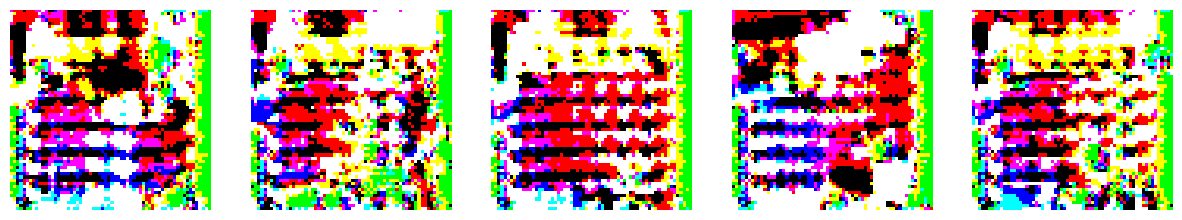

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import gc

# -----------------------------------------------------------------------------
# 0. SETUP
# -----------------------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 16,     
    "lr": 2e-4,
    "epochs": 15,
    "img_size": 64,
    "timesteps": 500,
    "embed_dim": 512,
    "output_dir": "stl10_diffusion_outputs"
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)

try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")

# -----------------------------------------------------------------------------
# 1. CLASS DEFINITIONS (Must be defined to load/run)
# -----------------------------------------------------------------------------
class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        full_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device='cpu')
        self.visual = full_model.visual
        self.visual.eval()
        del full_model
        gc.collect()
        self.register_buffer("mean", torch.tensor([0.481, 0.457, 0.408]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.268, 0.261, 0.275]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images):
        x = (images + 1) * 0.5
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = (x - self.mean) / self.std
        features = self.visual(x)
        return features.float() / features.norm(dim=-1, keepdim=True)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()
    def forward(self, x, t):
        h = self.bn1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bn2(self.relu(self.conv2(h)))
        return h

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        time_emb_dim = 128
        self.time_mlp = nn.Sequential(SinusoidalPositionEmbeddings(time_emb_dim), nn.Linear(time_emb_dim, time_emb_dim), nn.ReLU())
        self.clip_proj = nn.Sequential(nn.Linear(512, time_emb_dim), nn.ReLU())
        
        self.inc = Block(3, 64, time_emb_dim)
        self.down1 = Block(64, 128, time_emb_dim)
        self.down2 = Block(128, 256, time_emb_dim)
        self.pool = nn.MaxPool2d(2)
        
        self.bot1 = Block(256, 256, time_emb_dim)
        self.bot2 = Block(256, 256, time_emb_dim)
        
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.up_block1 = Block(128 + 256, 128, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.up_block2 = Block(64 + 128, 64, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(64, 64, 2, 2)
        self.up_block3 = Block(64 + 64, 64, time_emb_dim)
        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x, timestep, clip_emb):
        t = self.time_mlp(timestep) + self.clip_proj(clip_emb)
        x1 = self.inc(x, t)
        x2 = self.down1(self.pool(x1), t)
        x3 = self.down2(self.pool(x2), t)
        x4 = self.pool(x3)
        x4 = self.bot2(self.bot1(x4, t), t)
        x = self.up_block1(torch.cat([self.up1(x4), x3], dim=1), t)
        x = self.up_block2(torch.cat([self.up2(x), x2], dim=1), t)
        x = self.up_block3(torch.cat([self.up3(x), x1], dim=1), t)
        return self.outc(x)

class DiffusionScheduler:
    def __init__(self, timesteps=500, device="cpu"):
        self.timesteps = timesteps
        self.device = device
        self.betas = torch.linspace(0.0001, 0.02, timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_hat = torch.sqrt(self.alpha_hat)
        self.sqrt_one_minus_alpha_hat = torch.sqrt(1.0 - self.alpha_hat)

    def noise_images(self, x, t):
        sqrt_alpha = self.sqrt_alpha_hat[t][:, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alpha_hat[t][:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha * x + sqrt_one_minus * noise, noise

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.timesteps, size=(n,)).to(self.device)

# -----------------------------------------------------------------------------
# 2. GLOBAL TRAINING (Guarantees variables persist)
# -----------------------------------------------------------------------------
def run_training_global():
    # Load Data
    transform = T.Compose([T.Resize(64), T.ToTensor(), T.Normalize((0.5,),(0.5,))])
    dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    
    # Init Models
    print("Initializing models...")
    enc = CLIPEncoder().to(CONFIG['device'])
    unet = SimpleUNet().to(CONFIG['device'])
    diff = DiffusionScheduler(timesteps=CONFIG['timesteps'], device=CONFIG['device'])
    
    opt = optim.AdamW(unet.parameters(), lr=CONFIG['lr'])
    mse = nn.MSELoss()
    scaler = torch.cuda.amp.GradScaler()
    
    print(f"Starting Training ({CONFIG['epochs']} Epochs)...")
    
    for epoch in range(CONFIG['epochs']):
        unet.train()
        total_loss = 0
        for i, (images, _) in enumerate(loader):
            images = images.to(CONFIG['device'])
            t = diff.sample_timesteps(images.shape[0])
            x_t, noise = diff.noise_images(images, t)
            
            with torch.no_grad():
                clip_emb = enc(images)
            
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                pred_noise = unet(x_t, t, clip_emb)
                loss = mse(noise, pred_noise)
            
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            
            total_loss += loss.item()
            if i % 100 == 0: print(f"Ep {epoch+1} Batch {i} Loss: {loss.item():.4f}")
            
    # CRITICAL: SAVE MODEL IMMEDIATELY
    print("Saving model to disk...")
    torch.save(unet.state_dict(), "stl10_diffusion_saved.pth")
    print(" Model Saved Successfully.")
    
    return enc, unet, diff, dataset

# Run and capture variables
if __name__ == "__main__":
    enc, model, diff, ds = run_training_global()
    
    # Visualization Code (Only runs if training succeeds)
    print("Generating Visualization...")
    model.eval()
    car = next(img for img, l in ds if l == 2).unsqueeze(0).to(CONFIG['device'])
    ship = next(img for img, l in ds if l == 8).unsqueeze(0).to(CONFIG['device'])
    
    with torch.no_grad():
        emb1 = enc(car)
        emb2 = enc(ship)
        
        # Simple blend
        steps = 5
        alphas = np.linspace(0, 1, steps)
        fig, axes = plt.subplots(1, steps, figsize=(15, 3))
        
        for i, alpha in enumerate(alphas):
            mixed = (1-alpha)*emb1 + alpha*emb2
            x = torch.randn((1, 3, 64, 64)).to(CONFIG['device'])
            
            # Sampling
            for t_idx in reversed(range(1, diff.timesteps)):
                t = (torch.ones(1) * t_idx).long().to(CONFIG['device'])
                pred = model(x, t, mixed)
                
                a = diff.alphas[t][:, None, None, None]
                a_hat = diff.alpha_hat[t][:, None, None, None]
                b = diff.betas[t][:, None, None, None]
                noise = torch.randn_like(x) if t_idx > 1 else 0
                
                x = 1/torch.sqrt(a) * (x - ((1-a)/torch.sqrt(1-a_hat))*pred) + torch.sqrt(b)*noise
            
            img = (x.clamp(-1, 1) + 1) / 2
            axes[i].imshow(img.cpu().squeeze().permute(1, 2, 0).numpy())
            axes[i].axis('off')
            
    plt.savefig(f"{CONFIG['output_dir']}/final_blends_v4.png")
    print("Blends generated.")